
# Tarea 0: Setup & First Contact with All Three Datasets
## IELE756 --- Preparación y Análisis de Datos

**Group:** 7

**Team members**: Macarena Fraga, Sebastian Bolomey

**Region**: Region Metropolitana

**Date**: 12.03.2026

🐱 [**Click Here To Go To Our GitHub Repository**](https://github.com/sbolomey/IELE756-Group-7-REPO/tree/main)

## Import: Pandas, Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.3.3


# Part 1: Census 2024
---

## 1.1 Load
Loading the data

In [2]:
persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=["region", "comuna", "sexo", "edad",
             "p27_nacionalidad", "p27_nacionalidad_rec",
             "escolaridad", "sit_fuerza_trabajo"],
)

## 1.2 Inspect
### 1.2.1 Number of rows and columns.

In [3]:
persona.shape


(18480432, 8)

### 1.2.2 Data types

In [4]:
persona.dtypes

region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

### 1.2.3 First 10 rows.

In [5]:
persona.head(10)

,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


### 1.2.4 Null values

In [6]:
persona.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


## 1.3 Filter for "Region Metropolitana"

In [7]:
my_region = persona[persona["region"] == 13]
print(f"Rows in my region: {len(my_region):,}")

Rows in my region: 7,400,741


## 1.4 First look at nationality
Percentage of foreigners in the selected region.

In [8]:
foreign = my_region["p27_nacionalidad_rec"] \
    .value_counts(normalize=True)
print(f"foreign-born: {foreign.get('Extranjero', 0):.1%}")

foreign-born: 0.0%


# Part 2 - ENO: Notifiable Diseases
---

### 2.1 Load

In [9]:
eno = pd.read_csv(
    "20241218_base_eno_final.csv",
    sep=",", encoding="utf-8-sig", low_memory = False) #For small data like this I used this configuration so it treat a string in the file as it is.)
print(f"Total rows: {len(eno):,}")
print(eno.columns.tolist())

Total rows: 333,300
['_id', 'etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autoctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


**Data type**

In [10]:
eno.dtypes

_id                          int64
etapa_clinica               object
region                      object
seremi                      object
nacionalidad                object
cie_10_diagnostico          object
diagnostico                 object
Autoctono                   object
anho_notificacion            int64
ENO                         object
pueblo_indigena             object
nombre_instruccion          object
presenta_sintomas           object
sintomas                    object
consumo_agua_no_potable     object
antecedente_teniasis        object
imagenologia                object
manifestaciones             object
existe_coinfeccion          object
via_transmision             object
n_parejas_sexuales          object
uso_preservativo            object
pais_contagio               object
paciente_inmunosuprimido    object
vih                         object
pareja                      object
exantema_mpox               object
factores_exposicion         object
neumonia            

**10 most common diagnoses reported in this file**

In [11]:
print(eno['diagnostico'].value_counts().head(10))

diagnostico
no aplica                                                                                                  69772
PAROTIDITIS, SIN COMPLICACIONES                                                                            47123
SIFILIS PRECOZ, LATENTE                                                                                    24812
SIFILIS TARDIA, LATENTE                                                                                    24269
INFECCION GONOCOCICA DEL TRACTO GENITOURINARIO INFERIOR SIN ABSCESO PERIURETRAL O DE GLANDULA ACCESORIA    15399
HEPATITIS AGUDA TIPO A, CON COMA HEPATICO                                                                  13475
TOS FERINA DEBIDA A BORDETELLA PERTUSSIS                                                                   12762
SIFILIS, NO ESPECIFICADA                                                                                   12615
INFECCION, GONOCOCICA, NO ESPECIFICADA                                              

**Regions in this file and number of data for each region.**

In [12]:
print(eno['region'].value_counts().head(17))

region
Región Metropolitana de Santiago                       126669
Región del Biobío                                       38592
Región de Valparaíso                                    36373
Región de Coquimbo                                      21373
Región de Antofagasta                                   18302
Región de Los Lagos                                     17829
Región de Tarapacá                                      13778
Región de la Araucanía                                  11593
Región del Libertador General Bernardo OHiggins         10765
Región del Maule                                        10128
Región de Atacama                                        7008
Región de Arica y Parinacota                             6541
Región de Los Ríos                                       5581
Región de Magallanes y la Antártica Chilena              3208
Región del Ñuble                                         2818
Región de Aysén del General Carlos Ibáñez del Campo      2690
D

**Percentage of ENO in the Metropolitan Region**

In [13]:
metrop = eno["region"] \
    .value_counts(normalize=True)
print(f"% ena in RM: {metrop.get('Región Metropolitana de Santiago', 0):.1%}")

% ena in RM: 38.0%


### 2.2 Filter to region
Filtering data for the assigned region.

In [14]:
eno_region = eno[eno["region"] == "Región Metropolitana de Santiago"]
print(f"Rows in my region: {len(eno_region):,}".replace(",", "."))

Rows in my region: 126.669


### 2.3 Notifications by year
Number of notifications per year

In [15]:
notifsxyear = eno_region["anho_notificacion"].value_counts().sort_index()

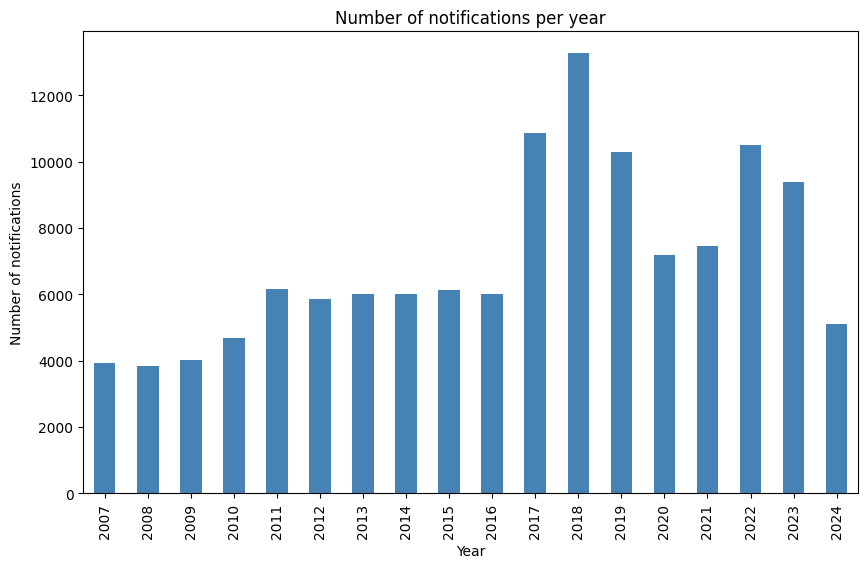

In [16]:
# Creating a bar chart
notifsxyear.plot(kind="bar", figsize=(10, 6), color="steelblue")

# Labels and title
plt.title("Number of notifications per year")
plt.xlabel("Year")
plt.ylabel("Number of notifications")

#Display chart
plt.show()

### 2.4 - Top 5 diseases
5 most frequently notified diseases in Region Metropolitana

In [17]:
top_5_diseases= eno_region["ENO"].value_counts().head(5)
print(top_5_diseases)

ENO
Sifilis                 40928
VIH                     29097
Parotiditis             15493
Infección gonocócica     8766
Hepatitis B              7565
Name: count, dtype: int64


### Displaying the top 5 most frequently notified diseases in Region Metropolitana as an horizontal bar chart

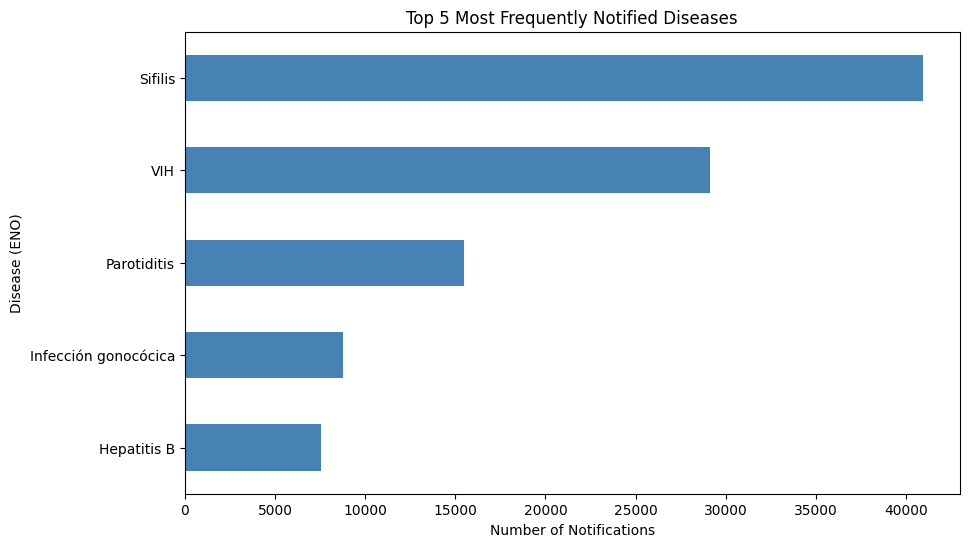

In [18]:
# Most frequent disease appear at the top
top_5_diseases = top_5_diseases.sort_values(ascending = True)

# For horizontal bar chart
top_5_diseases.plot(kind="barh", figsize=(10, 6), color="steelblue")

# Labels and title
plt.title("Top 5 Most Frequently Notified Diseases")
plt.xlabel("Number of Notifications")
plt.ylabel("Disease (ENO)")

#Display chart
plt.show()

### 2.5 Nationality distribution

In [19]:
nat_dist = eno_region["nacionalidad"].value_counts()
print(nat_dist)

nacionalidad
Desconocido    55863
Chile          47093
Extranjero     23713
Name: count, dtype: int64


**With a Pie Chart**

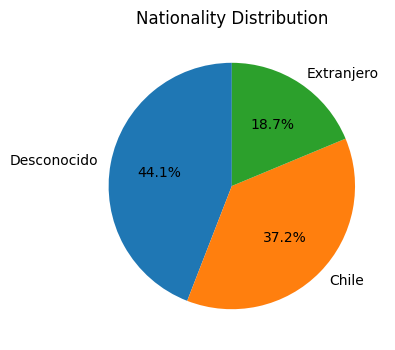

In [20]:
#Creating pie chart
nat_dist.plot(
    kind='pie', 
    figsize=(4, 4),          # Makes the chart a big square
    autopct='%1.1f%%',       # Calculates and shows the percentages
    startangle=90,           # Rotates the first slice to start at the top
    title="Nationality Distribution"    # Adds a title
)

plt.ylabel("")
plt.show()

## Part 3: GRD - Hospital Discharges
---

### 3.1 Load year 2024

In [21]:
import zipfile

cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
        "FECHA_INGRESO", "FECHAALTA",
        "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]

with zipfile.ZipFile("GRD_PUBLICO_2024.zip") as z:
    with z.open("GRD_PUBLICO_2024.txt") as f:
        grd = pd.read_csv(f, sep="|", usecols=cols,
                          low_memory=False, encoding="latin1")

print(f"Total discharges: {len(grd):,}")

Total discharges: 1,085,813


### 3.2 Filter to your region
In GRD there is no region column. Instead, COMUNA contains the commune name in uppercase (e.g., "IQUIQUE").

**But first we have to know what comunas are we working with. Therefore we use the comunas in the selected region.**
 

In [22]:
comunas = my_region['comuna'].unique().tolist()
print(comunas)
print(len(comunas))

[13124, 13101, 13603, 13501, 13107, 13119, 13126, 13123, 13106, 13401, 13120, 13130, 13503, 13605, 13113, 13127, 13110, 13201, 13602, 13302, 13301, 13114, 13111, 13103, 13128, 13115, 13102, 13132, 13108, 13105, 13125, 13122, 13131, 13129, 13104, 13121, 13117, 13404, 13604, 13112, 13118, 13402, 13403, 13109, 13116, 13601, 13203, 13505, 13303, 13502, 13202, 13504]
52


**The comunas are displayed as their territory name, so we first have to change them using the dictionary given by the Censo 2024.**

First we upload the given dictionary on xlsx.

In [23]:
# 1. Read the Excel file
comunas_df = pd.read_excel('diccionario_variables_censo2024.xlsx',sheet_name='codigos_territoriales')

# Printing the columns so you can see the exact names
print(comunas_df.columns.tolist())

['Código territorial', 'División Política Administrativa', 'Territorio']


Last, we create a dictionary so it can translate the comunas code number in our region into a string:

In [24]:
# 2. Creating dictionary 
codigo_a_nombre = dict(zip(comunas_df['Código territorial'], comunas_df['Territorio']))

# 3. Add the translated names directly to your original DataFrame
my_comunas = [codigo_a_nombre.get(codigo, "Desconocido") for codigo in comunas]

# Check the results
print(my_comunas)
print(len(my_comunas))

['Pudahuel', 'Santiago', 'Isla de Maipo', 'Melipilla', 'Huechuraba', 'Maipú', 'Quinta Normal', 'Providencia', 'Estación Central', 'San Bernardo', 'Ñuñoa', 'San Miguel', 'Curacaví', 'Peñaflor', 'La Reina', 'Recoleta', 'La Florida', 'Puente Alto', 'El Monte', 'Lampa', 'Colina', 'Las Condes', 'La Granja', 'Cerro Navia', 'Renca', 'Lo Barnechea', 'Cerrillos', 'Vitacura', 'Independencia', 'El Bosque', 'Quilicura', 'Peñalolén', 'San Ramón', 'San Joaquín', 'Conchalí', 'Pedro Aguirre Cerda', 'Lo Prado', 'Paine', 'Padre Hurtado', 'La Pintana', 'Macul', 'Buin', 'Calera de Tango', 'La Cisterna', 'Lo Espejo', 'Talagante', 'San José de Maipo', 'San Pedro', 'Tiltil', 'Alhué', 'Pirque', 'María Pinto']
52


In [25]:
my_comunas = ["COMUNA1", "COMUNA2", ...]  # your region's comunas
grd_region = grd[grd["COMUNA"].isin(my_comunas)]
print(f"Discharges in my region: {len(grd_region):,}")

Discharges in my region: 0


### 3.3 Join with CIE-10

The DIAGNOSTICO1 column contains ICD-10 codes (e.g., "J18.9"). To get human-readable names, join with the lookup table:

In [26]:
cie10 = pd.read_excel("CIE-10.xlsx",
                       sheet_name="CIE 10")

grd_region = grd_region.merge(
    cie10[["Código", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1", right_on="Código",
    how="left")

### 3.4 Top 5 diagnoses

Show the 5 most common diagnoses (by Descripción) in your region:

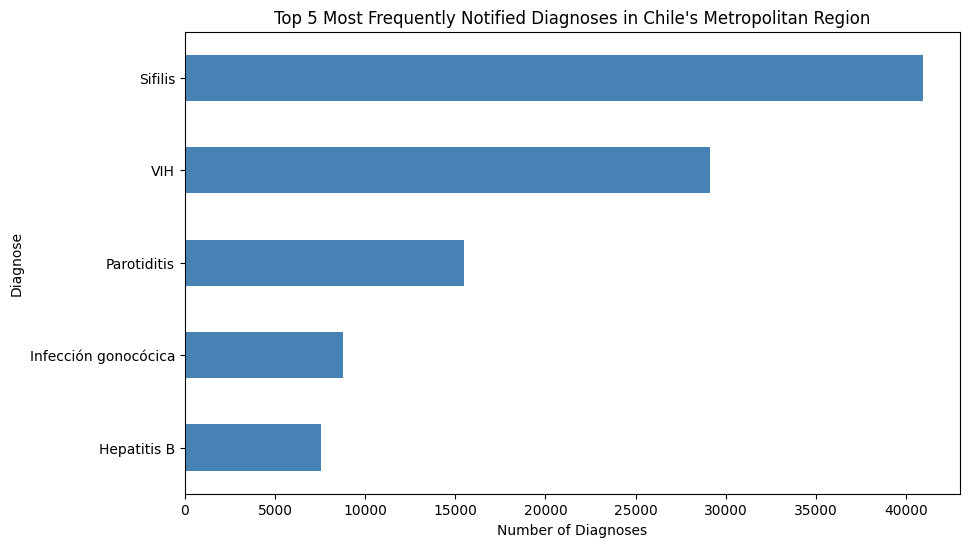

In [27]:
top_5_diagnoses = grd_region["Descripción"].value_counts().head(5)

# Most frequent diagnoses appear at the top
top_5_diagnoses = top_5_diseases.sort_values(ascending = True)

# For horizontal bar chart
top_5_diagnoses.plot(kind="barh", figsize=(10, 6), color="steelblue")

# Labels and title
plt.title("Top 5 Most Frequently Notified Diagnoses in Chile's Metropolitan Region")
plt.xlabel("Number of Diagnoses")
plt.ylabel("Diagnose")

# Display chart
plt.show()